In [12]:
import numpy as np 
import seaborn as sns
from PIL import TiffImagePlugin
import matplotlib.pyplot as plt 
import tensorflow as tf 
import os
from tensorflow.keras import layers , models , callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
np.random.seed(42)
tf.random.set_seed(42)

os.makedirs('images', exist_ok=True)
os.makedirs('models', exist_ok=True)

EDGE_TYPES = {
    0: 'Horizontal',  1: 'Vertical',
    2: 'Diag BL-TR',  3: 'Diag TL-BR',
    4: 'Corner TL',   5: 'Corner TR',
    6: 'Corner BL',   7: 'Corner BR',
    8: 'T-Top',       9: 'T-Bottom',
    10: 'Cross',      11: 'No Edge'
}
NUM_CLASSES = 12
PATCH_SIZE  = 5

print('Setup done. TF:', tf.__version__)


Setup done. TF: 2.20.0


In [4]:
model_v1 = tf.keras.models.load_model('models/edge_cnn_v1_final.keras')
model_v2 = tf.keras.models.load_model('models/edge_cnn_v2_final.keras')
print('Loaded: v1 and v2')

X_test = np.load('X_test_synthetic.npy')
y_test = np.load('y_test_synthetic.npy')
print(f'Test set: {X_test.shape[0]} samples')

Loaded: v1 and v2
Test set: 2400 samples


In [7]:
for name, mdl in [('v1 Synthetic Only', model_v1), ('v2 Natural Fine-tuned', model_v2)]:
    loss, acc = mdl.evaluate(X_test, y_test, verbose=0)
    y_pred = np.argmax(mdl.predict(X_test, verbose=0), axis=1)
    f1 = f1_score(y_test, y_pred, average='macro')
    print(f'--- {name} ---')
    print(f'  Accuracy : {acc*100:.2f}%')
    print(f'  Macro F1 : {f1:.4f}')
    print(f'  Loss     : {loss:.4f}\n')

--- v1 Synthetic Only ---
  Accuracy : 98.62%
  Macro F1 : 0.9862
  Loss     : 0.0391

--- v2 Natural Fine-tuned ---
  Accuracy : 98.54%
  Macro F1 : 0.9854
  Loss     : 0.0714



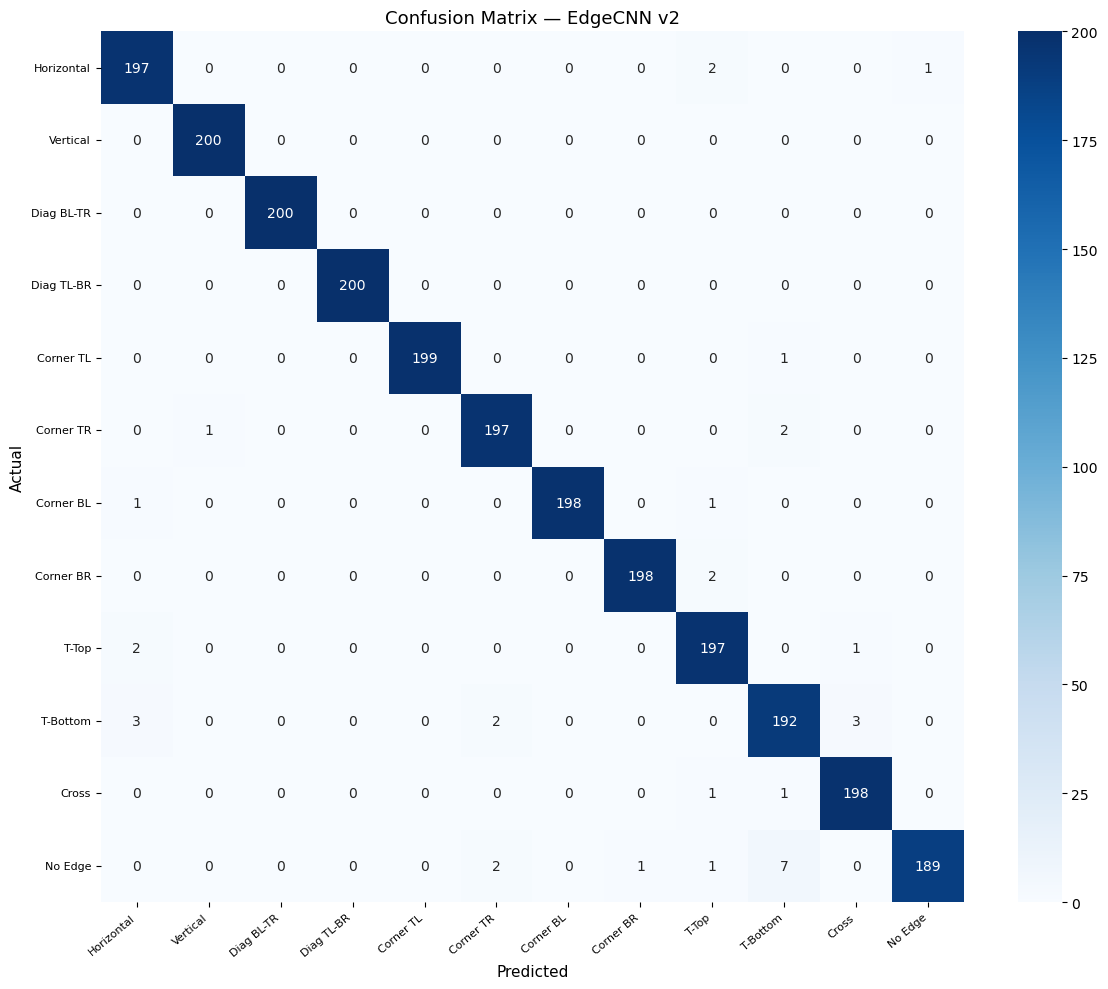

In [14]:
from sklearn.metrics import confusion_matrix
y_pred_v2 = np.argmax(model_v2.predict(X_test, verbose=0), axis=1)
cm = confusion_matrix(y_test, y_pred_v2)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(EDGE_TYPES.values()),
            yticklabels=list(EDGE_TYPES.values()), ax=ax)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
ax.set_title('Confusion Matrix — EdgeCNN v2', fontsize=13)
plt.xticks(rotation=40, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('images/confusion_matrix_v2.png', dpi=120)
plt.show()

C:\Users\pranj\AppData\Local\Temp\ipykernel_18332\2376452456.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(list(EDGE_TYPES.values()), rotation=35, ha='right', fontsize=8)


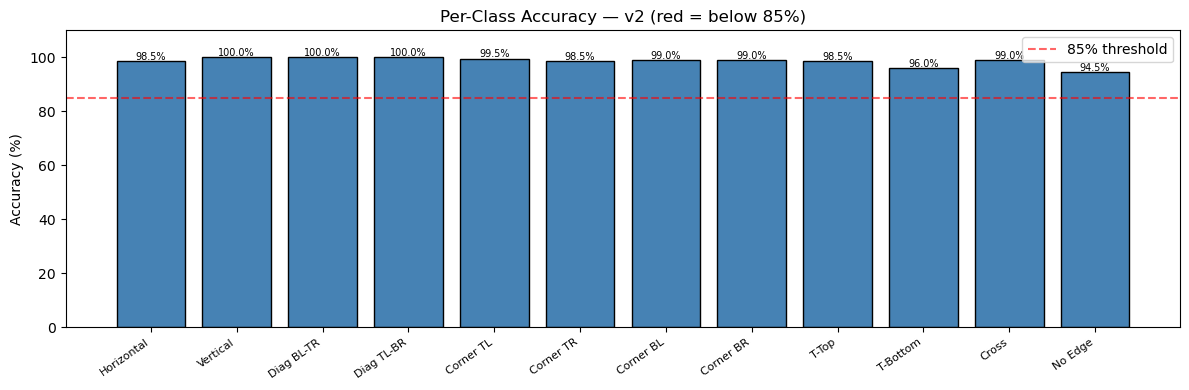

Weak classes (< 85%): None — all classes are strong!


In [17]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(12, 4))
colors = ['tomato' if a < 0.85 else 'steelblue' for a in per_class_acc]
bars = ax.bar(list(EDGE_TYPES.values()), per_class_acc * 100, color=colors, edgecolor='black')

for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc*100:.1f}%', ha='center', fontsize=7)

ax.axhline(85, linestyle='--', color='red', alpha=0.6, label='85% threshold')
ax.set_ylim(0, 110)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Class Accuracy — v2 (red = below 85%)', fontsize=12)
ax.set_xticklabels(list(EDGE_TYPES.values()), rotation=35, ha='right', fontsize=8)
ax.legend()
plt.tight_layout()
plt.savefig('images/per_class_accuracy.png', dpi=120)
plt.show()

weak = [EDGE_TYPES[i] for i, a in enumerate(per_class_acc) if a < 0.85]
print(f'Weak classes (< 85%): {weak if weak else "None — all classes are strong!"}')

In [19]:
from sklearn.metrics import accuracy_score
sigma_levels = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]
acc_v1_noisy, acc_v2_noisy = [], []

for sigma in sigma_levels:
    noise   = np.random.normal(0, sigma, X_test.shape).astype(np.float32)
    X_noisy = np.clip(X_test + noise, 0, 1)

    pred_v1 = np.argmax(model_v1.predict(X_noisy, verbose=0), axis=1)
    pred_v2 = np.argmax(model_v2.predict(X_noisy, verbose=0), axis=1)

    acc_v1_noisy.append(accuracy_score(y_test, pred_v1))
    acc_v2_noisy.append(accuracy_score(y_test, pred_v2))
    print(f'sigma={sigma:.2f}  ->  v1: {acc_v1_noisy[-1]*100:.1f}%  |  v2: {acc_v2_noisy[-1]*100:.1f}%')

sigma=0.00  ->  v1: 98.6%  |  v2: 98.5%
sigma=0.05  ->  v1: 98.4%  |  v2: 98.3%
sigma=0.10  ->  v1: 98.5%  |  v2: 98.2%
sigma=0.15  ->  v1: 97.6%  |  v2: 96.9%
sigma=0.20  ->  v1: 97.2%  |  v2: 96.0%
sigma=0.25  ->  v1: 94.2%  |  v2: 90.7%
sigma=0.30  ->  v1: 90.6%  |  v2: 85.0%
sigma=0.40  ->  v1: 78.7%  |  v2: 71.7%
sigma=0.50  ->  v1: 65.5%  |  v2: 57.2%


In [26]:
X_full = np.load('X_synthetic.npy')
y_full = np.load('y_synthetic.npy')

X_tr, X_vl, y_tr, y_vl = train_test_split(
    X_full, y_full, test_size=0.15, stratify=y_full, random_state=42
)

CONFIGS = [
    {'name': 'Wider',  'filters': [64, 128], 'dense': 256, 'dropout': 0.3,  'lr': 1e-3},
    {'name': 'Deeper', 'filters': [32, 64],  'dense': 128, 'dropout': 0.4,  'lr': 5e-4},
    {'name': 'Slim',   'filters': [16, 32],  'dense': 64,  'dropout': 0.25, 'lr': 1e-3},
]

results = {}

for cfg in CONFIGS:
    print(f"Training: {cfg['name']}...")

    m = models.Sequential([
        layers.Input(shape=(PATCH_SIZE, PATCH_SIZE, 1)),
        layers.Conv2D(cfg['filters'][0], (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(cfg['filters'][1], (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Flatten(),
        layers.Dense(cfg['dense'], activation='relu'),
        layers.Dropout(cfg['dropout']),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    m.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=cfg['lr']),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    h = m.fit(
        X_tr, y_tr,
        validation_data=(X_vl, y_vl),
        epochs=30,
        batch_size=64,
        callbacks=[
            callbacks.EarlyStopping(patience=6, restore_best_weights=True),
            callbacks.ReduceLROnPlateau(factor=0.5, patience=3)
        ],
        verbose=0
    )

    best_acc = max(h.history['val_accuracy'])
    results[cfg['name']] = {'model': m, 'val_acc': best_acc, 'history': h, 'cfg': cfg}
    print(f"  Best Val Accuracy: {best_acc*100:.2f}%")

print('\n--- Summary ---')
for name, res in results.items():
    print(f'{name}: {res["val_acc"]*100:.2f}%')

Training: Wider...
  Best Val Accuracy: 98.61%
Training: Deeper...
  Best Val Accuracy: 98.56%
Training: Slim...
  Best Val Accuracy: 98.72%

--- Summary ---
Wider: 98.61%
Deeper: 98.56%
Slim: 98.72%


In [27]:
best_name = max(results, key=lambda k: results[k]['val_acc'])
best_cfg  = results[best_name]['cfg']
print(f'Best config: {best_name}  ({results[best_name]["val_acc"]*100:.2f}% val acc)')
print(f'  Filters: {best_cfg["filters"]}  Dense: {best_cfg["dense"]}  Dropout: {best_cfg["dropout"]}')

Best config: Slim  (98.72% val acc)
  Filters: [16, 32]  Dense: 64  Dropout: 0.25


In [28]:
# Build v3 with best config + L2 regularization
model_v3 = models.Sequential([
    layers.Input(shape=(PATCH_SIZE, PATCH_SIZE, 1)),

    layers.Conv2D(best_cfg['filters'][0], (3, 3), activation='relu', padding='same',
                  kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),

    layers.Conv2D(best_cfg['filters'][1], (3, 3), activation='relu', padding='same',
                  kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(best_cfg['dense'], activation='relu',
                 kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.Dropout(best_cfg['dropout']),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name='EdgeCNN_v3')

model_v3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=best_cfg['lr']),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_v3.summary()

Model: "EdgeCNN_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 5, 5, 16)       │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 5, 5, 16)       │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 5, 5, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 5, 5, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,036 (222.80 KB)

 Trainable params: 56,940 (222.42 KB)

 Non-trainable params: 96 (384.00 B)

In [29]:
X_tr_v3, X_vl_v3, y_tr_v3, y_vl_v3 = train_test_split(
    X_full, y_full, test_size=0.12, stratify=y_full, random_state=99
)

history_v3 = model_v3.fit(
    X_tr_v3, y_tr_v3,
    validation_data=(X_vl_v3, y_vl_v3),
    epochs=50,
    batch_size=64,
    callbacks=[
        callbacks.EarlyStopping(patience=8, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(factor=0.5, patience=4, verbose=1),
        callbacks.ModelCheckpoint('models/edge_cnn_v3_best.keras',
                                  monitor='val_accuracy', save_best_only=True, verbose=1)
    ],
    verbose=1
)

Epoch 1/50
162/165 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8677 - loss: 0.4770
Epoch 1: val_accuracy improved from None to 0.49444, saving model to models/edge_cnn_v3_best.keras
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9511 - loss: 0.1902 - val_accuracy: 0.4944 - val_loss: 1.5330 - learning_rate: 0.0010
Epoch 2/50
155/165 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9840 - loss: 0.0696
Epoch 2: val_accuracy improved from 0.49444 to 0.95486, saving model to models/edge_cnn_v3_best.keras
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9822 - loss: 0.0719 - val_accuracy: 0.9549 - val_loss: 0.3211 - learning_rate: 0.0010
Epoch 3/50
150/165 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9860 - loss: 0.0602
Epoch 3: val_accuracy improved from 0.95486 to 0.97986, saving model to models/edge_cnn_v3_best.keras
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9854 - loss: 0.0633 - val_accuracy: 0.9799 - val_loss: 0.0769 - learning_rate: 0.0010
Epoch 4/50
163/1

In [31]:
model_names = ['v1 Synthetic', 'v2 Natural FT', 'v3 Tuned']
accuracies  = []

for name, mdl in [('v1 Synthetic Only', model_v1),
                  ('v2 Natural Fine-tuned', model_v2),
                  ('v3 Tuned Architecture', model_v3)]:
    loss, acc = mdl.evaluate(X_test, y_test, verbose=0)
    y_pred    = np.argmax(mdl.predict(X_test, verbose=0), axis=1)
    f1        = f1_score(y_test, y_pred, average='macro')
    accuracies.append(acc * 100)
    print(f'\n{name}')
    print(f'  Accuracy : {acc*100:.2f}%  |  Macro F1: {f1:.4f}  |  Loss: {loss:.4f}')


v1 Synthetic Only
  Accuracy : 98.62%  |  Macro F1: 0.9862  |  Loss: 0.0391

v2 Natural Fine-tuned
  Accuracy : 98.54%  |  Macro F1: 0.9854  |  Loss: 0.0714

v3 Tuned Architecture
  Accuracy : 99.17%  |  Macro F1: 0.9917  |  Loss: 0.0337


In [32]:
model_v3.save('models/edge_cnn_v3_final.keras')
print('Saved: models/edge_cnn_v3_final.keras')
print('Next: Run Notebook 5 — Final Evaluation on Real Images')

Saved: models/edge_cnn_v3_final.keras
Next: Run Notebook 5 — Final Evaluation on Real Images
